<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


## Solución del desafío

Paso 1: obtener y limpiar el corpus.

Para el presente desafío se seleccionó el libro Frankenstein dado que es un texto con estilo narrativo rico y posee un buen tamaño (~438 KB) para que el modelo tenga suficiente variedad de patrones sin volverse gigante para entrenar en Colab.

Los archivos de Gutenberg no son solo el texto de la novela, traen un header y un footer con la licencia y metadata del proyecto (líneas tipo *** START OF THE PROJECT GUTENBERG EBOOK *** y *** END OF THE PROJECT GUTENBERG EBOOK ***).Se prosede a eliminarlos.

Además, como voy a tokenizar por caracter, conviene pasar todo a minúsculas para no duplicar el vocabulario entre mayúsculas y minúsculas (así "A" y "a" son el mismo token, y el vocabulario queda más chico y manejable).

In [6]:
#Descarga del corpus
import urllib.request

url = "https://www.gutenberg.org/ebooks/84.txt.utf-8"
raw_text = urllib.request.urlopen(url).read().decode("utf-8")

# Recortamos el header y footer legal de Project Gutenberg
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = raw_text.find(start_marker)
start_idx = raw_text.find("\n", start_idx) + 1  # saltamos la línea del marcador
end_idx = raw_text.find(end_marker)

article_text = raw_text[start_idx:end_idx]

# pasamos todo a minúscula
article_text = article_text.lower()

print(f"Longitud del corpus crudo: {len(article_text)} caracteres")

Longitud del corpus crudo: 426704 caracteres


In [7]:
#Limpieza de saltos de línea

import re

# normalizamos \r\n -> \n y colapsamos cualquier secuencia de saltos de línea
# (simples o dobles, con o sin \r) en un solo espacio
article_text = re.sub(r"\r\n|\r|\n", " ", article_text)

# además colapsamos espacios múltiples que puedan quedar (ej. por líneas en blanco)
article_text = re.sub(r" +", " ", article_text).strip()

print(f"Longitud del corpus tras limpieza: {len(article_text)} caracteres")
print("¿Contiene \\r?:", "\r" in article_text)
print("¿Contiene \\n?:", "\n" in article_text)
print(article_text[:300])

Longitud del corpus tras limpieza: 418285 caracteres
¿Contiene \r?: False
¿Contiene \n?: False
frankenstein; or, the modern prometheus by mary wollstonecraft (godwin) shelley contents letter 1 letter 2 letter 3 letter 4 chapter 1 chapter 2 chapter 3 chapter 4 chapter 5 chapter 6 chapter 7 chapter 8 chapter 9 chapter 10 chapter 11 chapter 12 chapter 13 chapter 14 chapter 15 chapter 16 chapter 


Paso 2: vocabulario de caracteres

Importante: el scaffold original usa set(article_text) para armar el vocabulario, y como los sets en Python no garantizan un orden fijo, cada vez que corras esa celda de nuevo los índices asignados a cada caracter pueden cambiar. Por eso conviene ordenar el vocabulario explícitamente.

In [8]:
# el vocabulario es el conjunto único de caracteres, ordenado para que sea reproducible
chars_vocab = sorted(set(article_text))

print(f"Tamaño del vocabulario: {len(chars_vocab)}")
print(chars_vocab)

Tamaño del vocabulario: 59
[' ', '!', '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'æ', 'è', 'é', 'ê', 'ô', '—', '‘', '’', '“', '”']


In [9]:
# Armo los diccionarios
char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

Tamaño de contexto (max_context_size): el scaffold usaba 100. Como es un modelo por caracteres (no por palabras), 100 caracteres equivalen aproximadamente a 15-20 palabras de contexto. Se considera suficiente para que el modelo capture estructura de oración pero no tanto como para que el entrenamiento se vuelva muy pesado.

In [10]:
max_context_size = 100

Paso 3: tokenizar y armar las secuencias de entrenamiento

Convierto todo el corpus en una lista de índices enteros:

In [11]:
tokenized_text = [char2idx[ch] for ch in article_text]

print(f"Longitud del texto tokenizado: {len(tokenized_text)}")
tokenized_text[:50]

Longitud del texto tokenizado: 418285


[28,
 40,
 23,
 36,
 33,
 27,
 36,
 41,
 42,
 27,
 31,
 36,
 18,
 0,
 37,
 40,
 4,
 0,
 42,
 30,
 27,
 0,
 35,
 37,
 26,
 27,
 40,
 36,
 0,
 38,
 40,
 37,
 35,
 27,
 42,
 30,
 27,
 43,
 41,
 0,
 24,
 47,
 0,
 35,
 23,
 40,
 47,
 0,
 45,
 37]

Separar train/validación: el scaffold  corta el corpus en dos bloques contiguos: el último 10%  queda como validación, y el resto como entrenamiento.

Esto tiene sentido para un modelo de lenguaje: si mezclaras ventanas aleatorias, una ventana de validación podría solaparse casi completamente con una de entrenamiento (porque las ventanas se arman con un paso de 1 caracter), y el modelo "haría trampa" viendo casi el mismo texto en ambos conjuntos.

In [12]:
import numpy as np
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

print(f"Caracteres en train: {len(train_text)}")
print(f"Caracteres en val: {len(val_text)}")

Caracteres en train: 376385
Caracteres en val: 41900


In [13]:
tokenized_sentences_val = [val_text[init*max_context_size : (init+1)*max_context_size] for init in range(num_val)]

In [14]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

Armar estructura many-to-many: cada secuencia de entrenamiento predice la siguiente secuencia desplazada un caracter.

In [15]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

vocab_size = len(chars_vocab)

X shape: (376285, 100)
y shape: (376285, 100)


Paso 4: definir la arquitectura.

Un ajuste necesario en los datos: el modelo que arma el scaffold espera que cada timestep venga representado como un vector de longitud 1 (el índice del caracter), no como un escalar suelto. Hay que agregarle una dimensión extra al final.

In [16]:
X = X[..., np.newaxis]  # ahora (351558, 100, 1)

Y se queda como está, (351558, 100), porque sparse_categorical_crossentropy espera los targets como índices enteros, no como vectores.

Algunas observaciones:

Por qué utilizo one-hot y no Embedding: con un vocabulario de apenas 59 símbolos, un vector one-hot ya es chico y perfectamente manejable. No hay compresión que ganar metiendo una capa de Embedding entrenable (que sumaría parámetros sin aportar mucho con tan pocas categorías). Por eso el scaffold usa CategoryEncoding para convertir índice → one-hot, envuelta en TimeDistributed para aplicar esa transformación a cada paso de tiempo de la secuencia por separado.

Por qué return_sequences=True: necesitamos que la capa recurrente devuelva un output por cada timestep, porque y tiene un target por cada posición de la secuencia.

Los tres modelos a entrenar son variantes de la misma idea (una celda recurrente que mantiene un estado oculto a través del tiempo), pero difieren en cómo manejan la memoria a largo plazo:

+ SimpleRNN (Elman): la más simple, un solo estado oculto que se recalcula en cada paso. Es rápida pero sufre el problema de gradientes que se desvanecen en secuencias largas. Le cuesta "recordar" contexto de muchos caracteres atrás.


+ LSTM: agrega una celda de memoria separada del estado oculto, con tres compuertas (entrada, olvido, salida) que regulan qué información se guarda, se descarta o se expone. Maneja mejor dependencias largas, pero tiene ~4x más parámetros por celda que SimpleRNN → más lenta de entrenar.

+ GRU: un punto intermedio  que combina las compuertas de LSTM en solo dos (actualización y reset), sin celda de memoria separada. Suele rendir similar a LSTM con menos parámetros y más velocidad.


Creo una función que arma el modelo según el tipo de celda, así después es fácil comparar las tres opciones sin duplicar código:

In [17]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, LSTM, GRU, Dense
from keras.models import Sequential

def build_model(cell_type='LSTM', units=200, dropout=0.1):
    cell_map = {'SimpleRNN': SimpleRNN, 'LSTM': LSTM, 'GRU': GRU}
    RecurrentLayer = cell_map[cell_type]

    model = Sequential()
    model.add(TimeDistributed(
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        input_shape=(None, 1)
    ))
    model.add(RecurrentLayer(units, return_sequences=True, dropout=dropout))  # sin recurrent_dropout -> habilita cuDNN
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

model = build_model(cell_type='LSTM')
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 59)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       208,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 59)       │        11,859 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,859 (858.82 KB)

 Trainable params: 219,859 (858.82 KB)

 Non-trainable params: 0 (0.00 B)

Se observan 200 unidades LSTM × 4 compuertas, más la capa densa de salida.


Paso 5: entrenamiento con el callback de perplejidad

Algunas observaciones:

+ ¿Por qué no uso accuracy o loss para decidir cuándo parar? La loss (sparse_categorical_crossentropy) es una buena señal de optimización, pero la perplejidad es la métrica estándar en modelos de lenguaje porque tiene una interpretación intuitiva: es, en promedio, "entre cuántas opciones está dudando el modelo" al predecir el siguiente caracter. Una perplejidad de 10 significa que el modelo está, en promedio, tan confundido como si tuviera que elegir al azar entre 10 caracteres equiprobables. Como el vocabulario tiene 59 símbolos, arrancar cerca de perplejidad ~59 (o más) es normal y el objetivo es verla bajar bien por debajo de eso.

+ Cómo se calcula el callback: al final de cada época, toma las secuencias de validación, les pide al modelo la probabilidad que le asignó al caracter correcto en cada posición, y combina esas probabilidades con la fórmula de perplejidad. Cuanta más alta probabilidad le dio el modelo a los caracteres que realmente vinieron, más baja la perplejidad.

+ Early stopping integrado: el callback guarda el modelo (my_model.keras) cada vez que la perplejidad de validación mejora, y si pasan patience épocas sin mejora, corta el entrenamiento solo.


In [45]:
from tensorflow import keras
class PplCallback(keras.callbacks.Callback):
    def __init__(self, val_data, history_ppl, patience=5, model_path="my_model.keras"):
        self.val_data = val_data
        self.target = []
        self.padded = []
        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience
        self.model_path = model_path

        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))
                self.info.append((count, count + len_seq))
                count += len_seq

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        predictions = self.model.predict(self.padded, verbose=0)

        for start, end in self.info:
            probs = [predictions[idx_seq, -1, idx_vocab] for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]
            scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_path)
            print(f"Saved new model to {self.model_path}!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

In [ ]:
from tensorflow.keras.utils import pad_sequences

In [23]:
history_ppl = []
hist = model.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl)],
    batch_size=256
)

Epoch 1/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.6098
 mean perplexity: 7.651482940573681 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - loss: 2.3574
Epoch 2/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.0579
 mean perplexity: 6.5682104424815755 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 2.0178
Epoch 3/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.9227
 mean perplexity: 5.950711747626985 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 45s 31ms/step - loss: 1.8990
Epoch 4/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.8346
 mean perplexity: 5.544146426822234 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - loss: 1.8156
Epoch 5/20
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7637
 mean perplexity: 5.350526377238635 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 1.7487
Epoch 6/20
1468/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7073
 mea

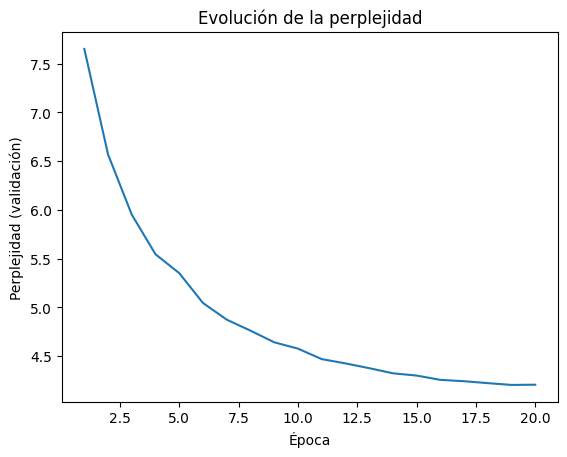

In [24]:
import matplotlib.pyplot as plt

epoch_count = range(1, len(history_ppl) + 1)
plt.plot(epoch_count, history_ppl)
plt.xlabel("Época")
plt.ylabel("Perplejidad (validación)")
plt.title("Evolución de la perplejidad")
plt.show()

# Cargamos el mejor modelo guardado (el de la época 19, no la 20)
model = keras.models.load_model("my_model.keras")

Observaciones:
+ Loss bajó de forma sostenida y suave: 2.61 → 1.43 en 20 épocas, sin saltos raros. Es una buena señal de que rmsprop está convergiendo bien.
+ Perplejidad de validación bajó de 7.65 a ~4.20. Con vocabulario de 59 caracteres, un modelo que no aprendió nada estaría cerca de perplejidad 59. Llegar a ~4.2 significa que el modelo, en promedio, "duda" entre apenas 4 caracteres candidatos por posición.
+ Detalle importante: en la época 20 la perplejidad subió levemente (4.2058 vs 4.2036 en la época 19). Es la primera vez que no mejora. El patience_counter pasó a 1, pero como patience=5, no llegó a activar el early stopping; el entrenamiento terminó porque se acabaron las 20 épocas, no porque el modelo dejó de mejorar. Esto sugiere que todavía tenía margen para seguir bajando un poco más si le dábamos más épocas.

Se propone entrar con más épocas para cortar por early stopping (se parte de los resultados obtenidos previamente).

In [25]:
ppl_callback = PplCallback(tokenized_sentences_val, history_ppl)
ppl_callback.min_score = min(history_ppl)  # continuamos desde el mejor puntaje ya logrado (~4.20)

hist2 = model.fit(
    X, y,
    epochs=15,
    callbacks=[ppl_callback],
    batch_size=256
)

Epoch 1/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4360
 mean perplexity: 4.177693131430906 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - loss: 1.4344
Epoch 2/15
1468/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.4288
 mean perplexity: 4.174019171116176 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - loss: 1.4267
Epoch 3/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.4212
 mean perplexity: 4.1389491393059705 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - loss: 1.4196
Epoch 4/15
1468/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.4142
 mean perplexity: 4.145411725829495 

1470/1470 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 1.4127
Epoch 5/15
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.4073
 mean perplexity: 4.12692937247793 

Saved new model!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - loss: 1.4064
Epoch 6/15
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.4009
 mean perplexity: 4.11

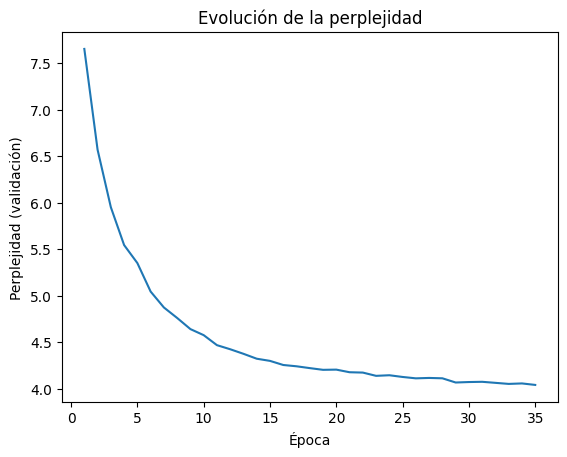

In [31]:
epoch_count = range(1, len(history_ppl) + 1)
plt.plot(epoch_count, history_ppl)
plt.xlabel("Época")
plt.ylabel("Perplejidad (validación)")
plt.title("Evolución de la perplejidad")
plt.show()

model = keras.models.load_model("my_model.keras")

Bajó de 4.20 a ~4.04. Mejoró, pero con rendimientos decrecientes: en las primeras 20 épocas bajó 3.45 puntos, en estas 15 adicionales bajó solo 0.16. Mirando el patrón de "Saved new model" (guardó en las épocas 1, 2, 3, 5, 6, 9, 12, 13, 15. Nunca faltó 5 seguidas, por eso no disparó el early stopping), el modelo sigue mejorando pero cada vez más de a poco. Es una señal típica de que se está acercando a una meseta.

Se propone frenar el entrenamiento con el resultado de ~4.04 de perplejidad y avanzar con el desafío.


Paso 7: predicción del próximo caracter

Antes de generar secuencias largas, conviene probar la función más básica: dado un texto de entrada, ¿qué caracter predice el modelo a continuación? Esto nos sirve para validar que el pipeline de encoding/predicción/decoding funciona bien.

In [35]:
# tomamos un fragmento real de 100 caracteres del texto, en algún punto intermedio
idx_prueba = 5000
fragmento = article_text[idx_prueba : idx_prueba + max_context_size]
siguiente_real = article_text[idx_prueba + max_context_size]

prediccion = predict_next_char(model, fragmento)

print("Fragmento:", repr(fragmento))
print("Caracter real siguiente:", repr(siguiente_real))
print("Predicción del modelo:", repr(prediccion))

Fragmento: 'atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and'
Caracter real siguiente: ' '
Predicción del modelo: ' '


In [36]:
# tomamos un fragmento real de 100 caracteres del texto, en algún punto intermedio
idx_prueba = 101234
fragmento = article_text[idx_prueba : idx_prueba + max_context_size]
siguiente_real = article_text[idx_prueba + max_context_size]

prediccion = predict_next_char(model, fragmento)

print("Fragmento:", repr(fragmento))
print("Caracter real siguiente:", repr(siguiente_real))
print("Predicción del modelo:", repr(prediccion))

Fragmento: 'l excellence and endeavoured to imitate her phraseology and manners, so that even now she often remi'
Caracter real siguiente: 'n'
Predicción del modelo: 'n'


In [38]:
# tomamos un fragmento real de 100 caracteres del texto, en algún punto intermedio
idx_prueba = 19521
fragmento = article_text[idx_prueba : idx_prueba + max_context_size]
siguiente_real = article_text[idx_prueba + max_context_size]

prediccion = predict_next_char(model, fragmento)

print("Fragmento:", repr(fragmento))
print("Caracter real siguiente:", repr(siguiente_real))
print("Predicción del modelo:", repr(prediccion))

Fragmento: 'tulated for his safety, your surprise would have been boundless. his limbs were nearly frozen, and h'
Caracter real siguiente: 'i'
Predicción del modelo: 'e'


2 de 3 estimaciones exactas. La que falló ('e' en vez de 'i') tampoco está mal: después de "...were nearly frozen, and h" el modelo predijo que sigue "he" (razonable gramaticalmente), cuando en realidad el libro dice "his". Es un error de sentido, no de sintaxis. El modelo entendió la estructura del idioma, aunque no siempre acierte la palabra exacta que eligió el autor.

Paso 8: generación greedy de secuencias completas.

Ahora encadeno la predicción caracter a caracter: predigo uno, lo agregáo al texto, vuelvo a predecir el siguiente usando el texto ya extendido como nuevo contexto, y repeto n veces.

In [39]:
def generate_seq(model, seed_text, max_length, n_chars):
    """
    Genera texto de forma greedy, un caracter a la vez.

    Args:
        model: modelo entrenado
        seed_text (str): texto inicial (prompt)
        max_length (int): tamaño de contexto que espera el modelo
        n_chars (int): cantidad de caracteres a generar
    Returns:
        str: seed_text + los caracteres generados
    """
    output_text = seed_text

    for _ in range(n_chars):
        encoded = [char2idx[ch] for ch in output_text.lower()]
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

        y_hat = np.argmax(model.predict(encoded, verbose=0)[0, -1, :])
        output_text += idx2char[y_hat]

    return output_text

In [40]:
seed = article_text[5000:5000+100]  # mismo fragmento de 100 caracteres que probamos antes
print("Seed:", seed)
print()
print("Generado:")
print(generate_seq(model, seed, max_length=max_context_size, n_chars=200))

Seed: atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and

Generado:
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and i was an incidents which i had not suffered the strange of the most destroyed the stranger and the monster of my father with a man who was surprised to me the morning i had a residence of the most de


Observaciones:
Sintaxis muy sólida: usa artículos, preposiciones, conjunciones en los lugares correctos ("an under-mate", "the strange of the most", "a residence of the most"). El modelo claramente aprendió la "forma" del inglés.

Pero hay un patrón repetitivo delator: aparece "the most de..." dos veces (casi idéntico: "the most destroyed" cerca del principio del texto generado, y "the most de" justo al final, cortado).Como en cada paso el modelo elige siempre el caracter más probable, sin ninguna aleatoriedad, si en algún momento entra en una zona del espacio de estados donde "the most de..." es una combinación de alta probabilidad, tiende a volver a caer ahí generando loops o frases recurrentes en vez de explorar variedad.

Semánticamente el texto no tiene mucho sentido (no cuenta una historia coherente), pero eso es esperable para un modelo char-level relativamente chico entrenado en minutos.

Paso 9: beam search: determinístico y estocástico

La idea central de beam search: en vez de quedarse solo con el caracter más probable en cada paso (como greedy), mantiene las k secuencias más prometedoras en paralelo. En cada paso, expande cada una de esas k secuencias con todos los caracteres posibles del vocabulario, calcula la probabilidad acumulada de cada combinación resultante, y se queda con las k mejores de todas esas combinaciones. Esto genera más "memoria" de alternativas: una secuencia que arrancó levemente peor pero termina siendo mejor en conjunto tiene chance de sobrevivir, cosa que greedy nunca permite.


Modo determinístico (mode='det'): en cada paso, de todas las combinaciones posibles (num_beams secuencias × vocab_size caracteres candidatos), se queda con las num_beams de mayor probabilidad acumulada, sin ningún azar. Es reproducible: correrlo dos veces con el mismo input da el mismo resultado.

Modo estocástico (mode='sto'): en vez de tomar directamente las mejores, hece un muestreo aleatorio ponderado por probabilidad (np.random.choice(..., p=softmax(...))). Las combinaciones más probables tienen más chances de ser elegidas, pero no es garantizado. Esto introduce variedad entre corridas y es la clave para evitar los loopsque se vieron con greedy.

In [41]:
from scipy.special import softmax

def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])


def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp))
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select//vocab_size], np.array([idx_select%vocab_size]).T),
        axis=1
    )
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode='det'):
    encoded = encode(input)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )

    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i+1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input)+num_words):]

Se prueban las tres variantes con el mismo seed real para poder comparar de forma justa:

In [42]:
seed = article_text[5000:5000+100]

# Beam search determinístico
salidas_det = beam_search(model, num_beams=5, num_words=100, input=seed, mode='det')
print("=== Determinístico ===")
print(decode(salidas_det[0]))
print()

# Beam search estocástico, temperatura baja (conservador)
salidas_sto_baja = beam_search(model, num_beams=5, num_words=100, input=seed, temp=0.5, mode='sto')
print("=== Estocástico, temp=0.5 ===")
print(decode(salidas_sto_baja[0]))
print()

# Beam search estocástico, temperatura alta (más aleatorio)
salidas_sto_alta = beam_search(model, num_beams=5, num_words=100, input=seed, temp=1.5, mode='sto')
print("=== Estocástico, temp=1.5 ===")
print(decode(salidas_sto_alta[0]))

=== Determinístico ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and when they were discovered on the cottagers of the miserable of the morning which i had been allowed

=== Estocástico, temp=0.5 ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and the same desire to heard that the monster destroyed the cottagers of the most destroyed the same fa

=== Estocástico, temp=1.5 ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and my immension. i will not be destroyed to your fact that i was about to geneva. they were at new man


Observaciones:

Existe un trade-off claro entre coherencia y diversidad. Greedy y beam con temperatura baja son más "seguros" gramaticalmente pero caen en repeticiones. Literalmente el mismo fragmento "the most de..." aparece en dos de las cuatro corridas, mostrando que es una zona de alta probabilidad en la que el modelo tiende a caer.

La temperatura alta (1.5) rompe ese patrón y genera texto más variado y hasta temáticamente relevante (menciona Geneva, que es donde efectivamente transcurre parte de la novela), a costa de empezar a inventar palabras que no existen.


Paso 10: se propone continuar con el desafío y entrenar una GRU para comparar perplejidad.

In [43]:
# guardamos una referencia aparte al LSTM ya entrenado, antes de tocar `model`
model_lstm = model
history_ppl_lstm = history_ppl.copy()

print(f"Mejor perplejidad LSTM: {min(history_ppl_lstm):.4f}")

Mejor perplejidad LSTM: 4.0414


In [44]:
# Armamos y entrenamos el GRU, con su propia lista de historial y su propio callback

model_gru = build_model(cell_type='GRU')
model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 59)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       156,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 59)       │        11,859 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,459 (658.04 KB)

 Trainable params: 168,459 (658.04 KB)

 Non-trainable params: 0 (0.00 B)

68,459 parámetros vs. 219,859 del LSTM:un 23% menos.

In [46]:
history_ppl_gru = []
hist_gru = model_gru.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru, model_path="my_model_gru.keras")],
    batch_size=256
)

Epoch 1/20
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.4453
 mean perplexity: 5.85046538248267 

Saved new model to my_model_gru.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - loss: 2.1453
Epoch 2/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.7556
 mean perplexity: 4.780050400617868 

Saved new model to my_model_gru.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 1.6946
Epoch 3/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.5631
 mean perplexity: 4.397485901461581 

Saved new model to my_model_gru.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - loss: 1.5352
Epoch 4/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.4698
 mean perplexity: 4.228042697565083 

Saved new model to my_model_gru.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 1.4536
Epoch 5/20
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.4130
 mean perplexity: 4.171152636657752 

Saved new model to my_model_gru.keras!
1470/1470 ━━━━━━━━━━━━━━━━

Observaciones:

El GRU llegó a una perplejidad muy cercana a la del LSTM (4.12 vs 4.04, una diferencia chica) en solo 8 épocas, mientras que el LSTM necesitó acumular 35 épocas (20 + 15 de la segunda tanda) para bajar de 4.20 a 4.04. El GRU convergió mucho más rápido por época y con menos parámetros, llegó casi al mismo lugar en una fracción del tiempo total de entrenamiento,  pero después se "estancó" y el early stopping cortó automáticamente, mientras que el LSTM, más lento para converger, todavía tenía algo de margen para seguir mejorando de a poco. Es un ejemplo real y concreto del trade-off donde menos parámetros tiende a ser  más rápido, pero potencialmente menor capacidad para seguir extrayendo patrones finos.

Paso 11: se popone entrenar una RNN simple y comprar los 3 resultados.

In [47]:
model_simplernn = build_model(cell_type='SimpleRNN')
model_simplernn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 59)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        52,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 59)       │        11,859 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,859 (249.45 KB)

 Trainable params: 63,859 (249.45 KB)

 Non-trainable params: 0 (0.00 B)

63,859 parámetros: apenas el 29% de los que tiene el LSTM (219,859) y el 38% de los del GRU (168,459).

In [48]:
history_ppl_simplernn = []
hist_simplernn = model_simplernn.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_simplernn, model_path="my_model_simplernn.keras")],
    batch_size=256
)

Epoch 1/20
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.3436
 mean perplexity: 6.00228700376069 

Saved new model to my_model_simplernn.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - loss: 2.0964
Epoch 2/20
1468/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7953
 mean perplexity: 5.197288589432017 

Saved new model to my_model_simplernn.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 66s 19ms/step - loss: 1.7533
Epoch 3/20
1467/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6632
 mean perplexity: 4.864287137416212 

Saved new model to my_model_simplernn.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - loss: 1.6457
Epoch 4/20
1469/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6031
 mean perplexity: 4.728565754924583 

Saved new model to my_model_simplernn.keras!
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - loss: 1.5924
Epoch 5/20
1468/1470 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5664
 mean perplexity: 4.623128339043665 

Saved new model to my_model_simplernn.ker

Observaciones:

Con solo el 29% de los parámetros del LSTM, SimpleRNN llegó a una perplejidad de 4.35, lo que es bastante cerca de 4.12 (GRU) y 4.04 (LSTM). Y fue claramente el más rápido por época (~27s vs ~41-44s de los otros dos, casi la mitad).


Por qué probablemente pasó esto: el problema de vanishing gradients en SimpleRNN se vuelve realmente grave en secuencias muy largas (cientos o miles de pasos) o en tareas donde hace falta recordar dependencias de largísimo plazo. Con max_context_size=100 y un vocabulario chico de 59 símbolos, la tarea es exigente pero no extrema. El modelo puede apoyarse bastante en dependencias de corto y mediano plazo (qué letra suele seguir a qué combinación reciente) sin necesitar memoria perfecta de los 100 caracteres completos. Es un buen ejemplo real de que las arquitecturas más sofisticadas (LSTM/GRU) no siempre justifican su costo computacional extra si la tarea no exige memoria de largo alcance.

LSTM ganó, pero por un margen bastante más chico del que su complejidad adicional (3.4x más parámetros que SimpleRNN) haría suponer.

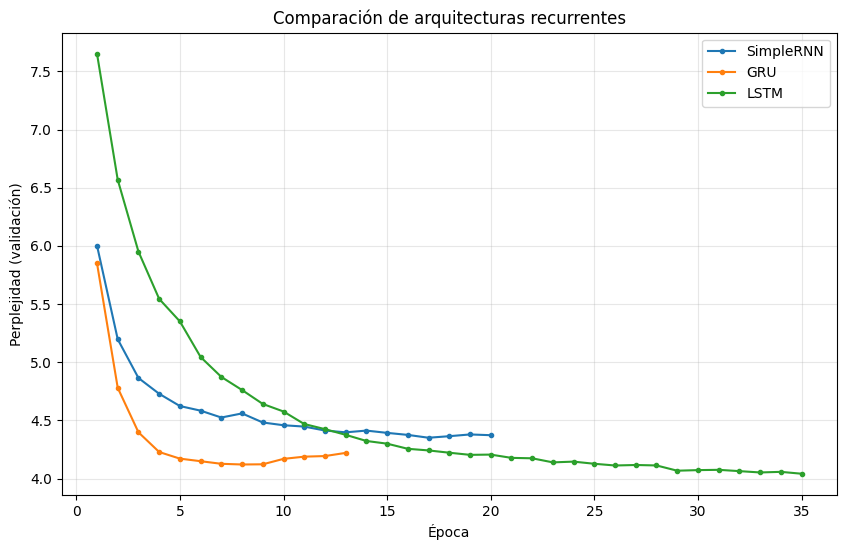

In [52]:
# Grafico de curvas

history_ppl_gru = [5.85046538248267, 4.780050400617868, 4.397485901461581, 4.228042697565083,
                    4.171152636657752, 4.14905164406806, 4.126656618778347, 4.120794964291885,
                    4.122384851473897, 4.169140282564914, 4.18804552390069, 4.1932701706032764,
                    4.220349340279518]

history_ppl_simplernn = [6.00228700376069, 5.197288589432017, 4.864287137416212, 4.728565754924583,
                          4.623128339043665, 4.583456205581993, 4.524458454446178, 4.55987549738554,
                          4.481800465708985, 4.45817980220039, 4.446631112360442, 4.412760236667278,
                          4.397204880498189, 4.41217097860532, 4.392515089745169, 4.375062180589662,
                          4.3507051263048995, 4.363975945406711, 4.378984041031903, 4.3725603138916815]


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_ppl_simplernn) + 1), history_ppl_simplernn, label='SimpleRNN', marker='o', markersize=3)
plt.plot(range(1, len(history_ppl_gru) + 1), history_ppl_gru, label='GRU', marker='o', markersize=3)
plt.plot(range(1, len(history_ppl_lstm) + 1), history_ppl_lstm, label='LSTM', marker='o', markersize=3)
plt.xlabel("Época")
plt.ylabel("Perplejidad (validación)")
plt.title("Comparación de arquitecturas recurrentes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Las tres curvas se encuentran bien diferenciadas, se ve perfecto cómo LSTM arranca peor (más parámetros, tarda más en converger) pero termina más bajo, mientras que GRU y SimpleRNN convergen rápido y se estancan antes.

In [50]:
seed = article_text[5000:5000+100]

for nombre, modelo in [("SimpleRNN", model_simplernn), ("GRU", model_gru), ("LSTM", model_lstm)]:
    print(f"=== {nombre} ===")
    print(generate_seq(modelo, seed, max_length=max_context_size, n_chars=150))
    print()

=== SimpleRNN ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and the stranger of the same cannot considerate the stranger of the same cannot considerate the stranger of the same cannot considerate the stranger of t

=== GRU ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and i was about to use to see you in your hands, and the sun soon be a sensation of my friends who was not sufficient to see the destroyer of the seasons

=== LSTM ===
atest practical advantage. twice i actually hired myself as an under-mate in a greenland whaler, and i was an incidents which i had not suffered the strange of the most destroyed the stranger and the monster of my father with a man who was surprised 



SimpleRNN cayó en el peor loop de los tres: "the stranger of the same cannot considerate" se repite tres veces seguidas, un loop mucho más agresivo que el de LSTM.

El punto central para destacar: SimpleRNN tuvo una perplejidad final (4.35) relativamente cercana a la de GRU (4.12) y LSTM (4.04). Una diferencia de apenas ~0.3, que numéricamente parece poca cosa. Pero la calidad de generación greedy fue notoriamente peor: cayó en el loop más marcado de los tres modelos, mientras que GRU generó el texto más variado y sin repeticiones evidentes de los tres. Esto demuestra que la perplejidad de validación no cuenta toda la historia: es un promedio de qué tan bien el modelo predice el siguiente caracter dado contexto real del corpus, pero no mide directamente la tendencia del modelo a quedar atrapado en atractores de alta probabilidad durante la generación autoregresiva. Un modelo con memoria más débil (como SimpleRNN, por el problema de vanishing gradients) parece más propenso a "engancharse" en patrones locales repetitivos una vez que entra en uno, porque tiene menos capacidad de usar contexto lejano para "darse cuenta" de que está repitiendo y salir del ciclo.

### Conclusiones finales

**Sobre el preprocesamiento:** se descargó el texto de *Frankenstein* (Mary Shelley) de Project Gutenberg como texto plano, recortando el header/footer legal del proyecto y normalizando saltos de línea (`\r\n`) en espacios, para evitar que el modelo aprendiera artefactos de formato en vez de estructura real del lenguaje. El vocabulario de caracteres resultante tiene 59 símbolos (26 letras, dígitos, puntuación, y algunos caracteres especiales de época como `æ`, comillas tipográficas `“ ”`).

**Sobre la arquitectura:** se compararon tres celdas recurrentes (SimpleRNN, GRU, LSTM) bajo la misma estructura many-to-many, mismo tamaño de contexto (100 caracteres) y mismo criterio de entrenamiento (callback de perplejidad con early stopping, patience=5).

| Arquitectura | Parámetros | Mejor perplejidad (val.) | Épocas hasta converger |
|---|---|---|---|
| SimpleRNN | 63,859 | 4.35 | 20 (no llegó a early stopping) |
| GRU | 168,459 | 4.12 | 8 (early stopping en época 13) |
| LSTM | 219,859 | 4.04 | ~30 (tras 35 épocas totales, en 2 tandas) |


LSTM logró la mejor perplejidad final, pero a costa de bastantes más épocas de entrenamiento. GRU ofreció el mejor balance costo/beneficio: perplejidad muy cercana a LSTM, alcanzada en una fracción de las épocas. SimpleRNN, pese a tener una perplejidad numérica no muy alejada de las otras dos, mostró la peor calidad de generación (mayor tendencia a loops repetitivos), sugiriendo que perplejidad de validación y calidad de generación autoregresiva no siempre están perfectamente correlacionadas.

**Sobre las estrategias de generación:** greedy search es la más rápida pero la más propensa a quedar atrapada en loops de alta probabilidad local (se observó el patrón "the most de..." repetido con el LSTM, y un loop más severo con SimpleRNN). Beam search determinístico mitiga parcialmente este problema al mantener varias hipótesis en paralelo, pero sigue siendo determinista y puede converger a patrones similares. La variante estocástica con temperatura demostró ser la herramienta más efectiva para escapar de repeticiones: con temperatura baja (0.5) el comportamiento se asemeja al determinístico, mientras que con temperatura alta (1.5) el texto generado gana diversidad léxica y temática (llegó a mencionar "geneva", lugar real de la novela) a costa de ocasionalmente producir palabras inexistentes.